# Before You Start

* **What is Masked Language Modeling ?**
> **Masked language modeling** predicts a masked token in a sequence, and the model can attend to tokens bidirectionally. This means the model has full access to the tokens on the left and right. Masked language modeling is great for tasks that require a good contextual understanding of an entire sequence. BERT is an example of a masked language model.

<center>

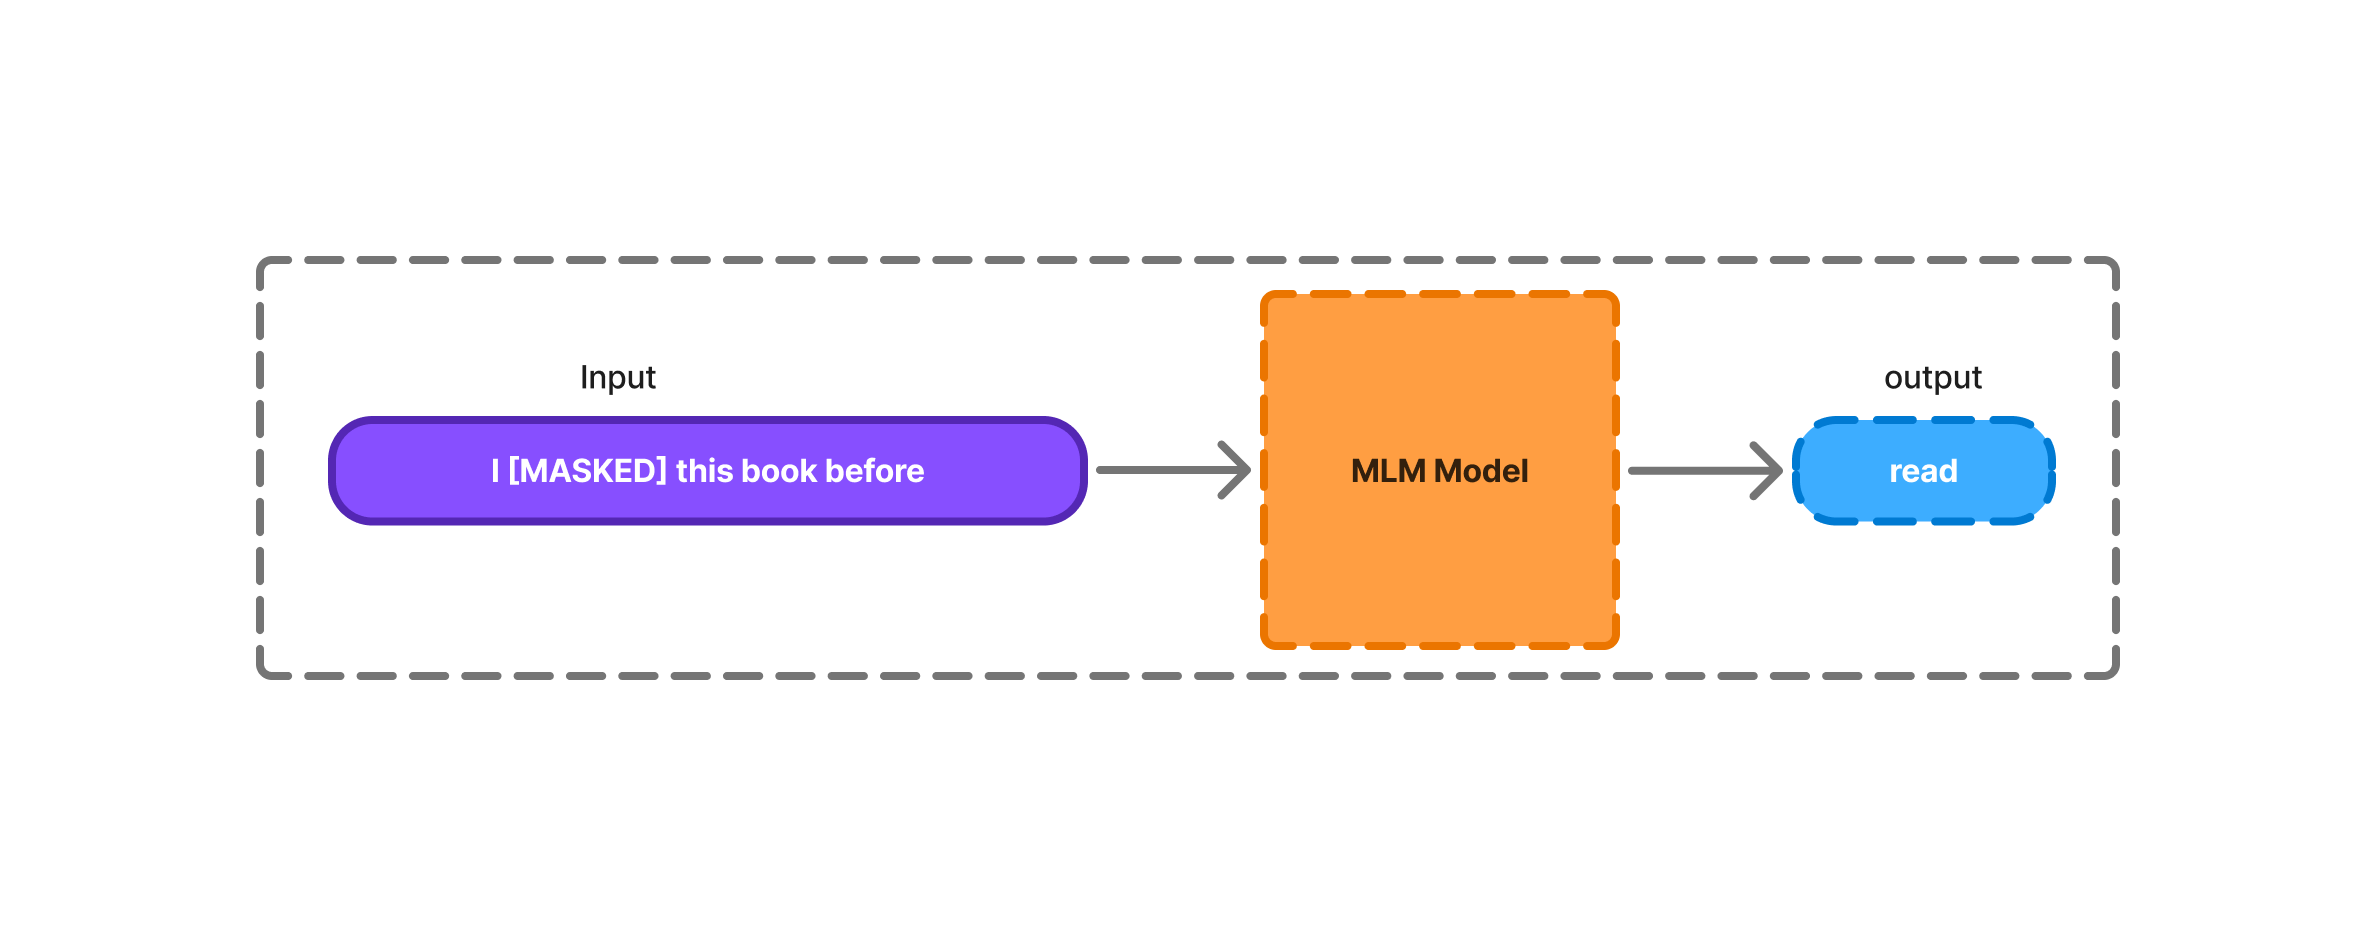
</center>

 * **How can Masked Language Modeling be used in transfer learning for downstream NLP tasks?**


> Once pretrained, these models can be fine-tuned on specific downstream NLP tasks, even with relatively small labeled datasets. The idea is that the model already understands language patterns, so it can adapt quickly to new tasks.

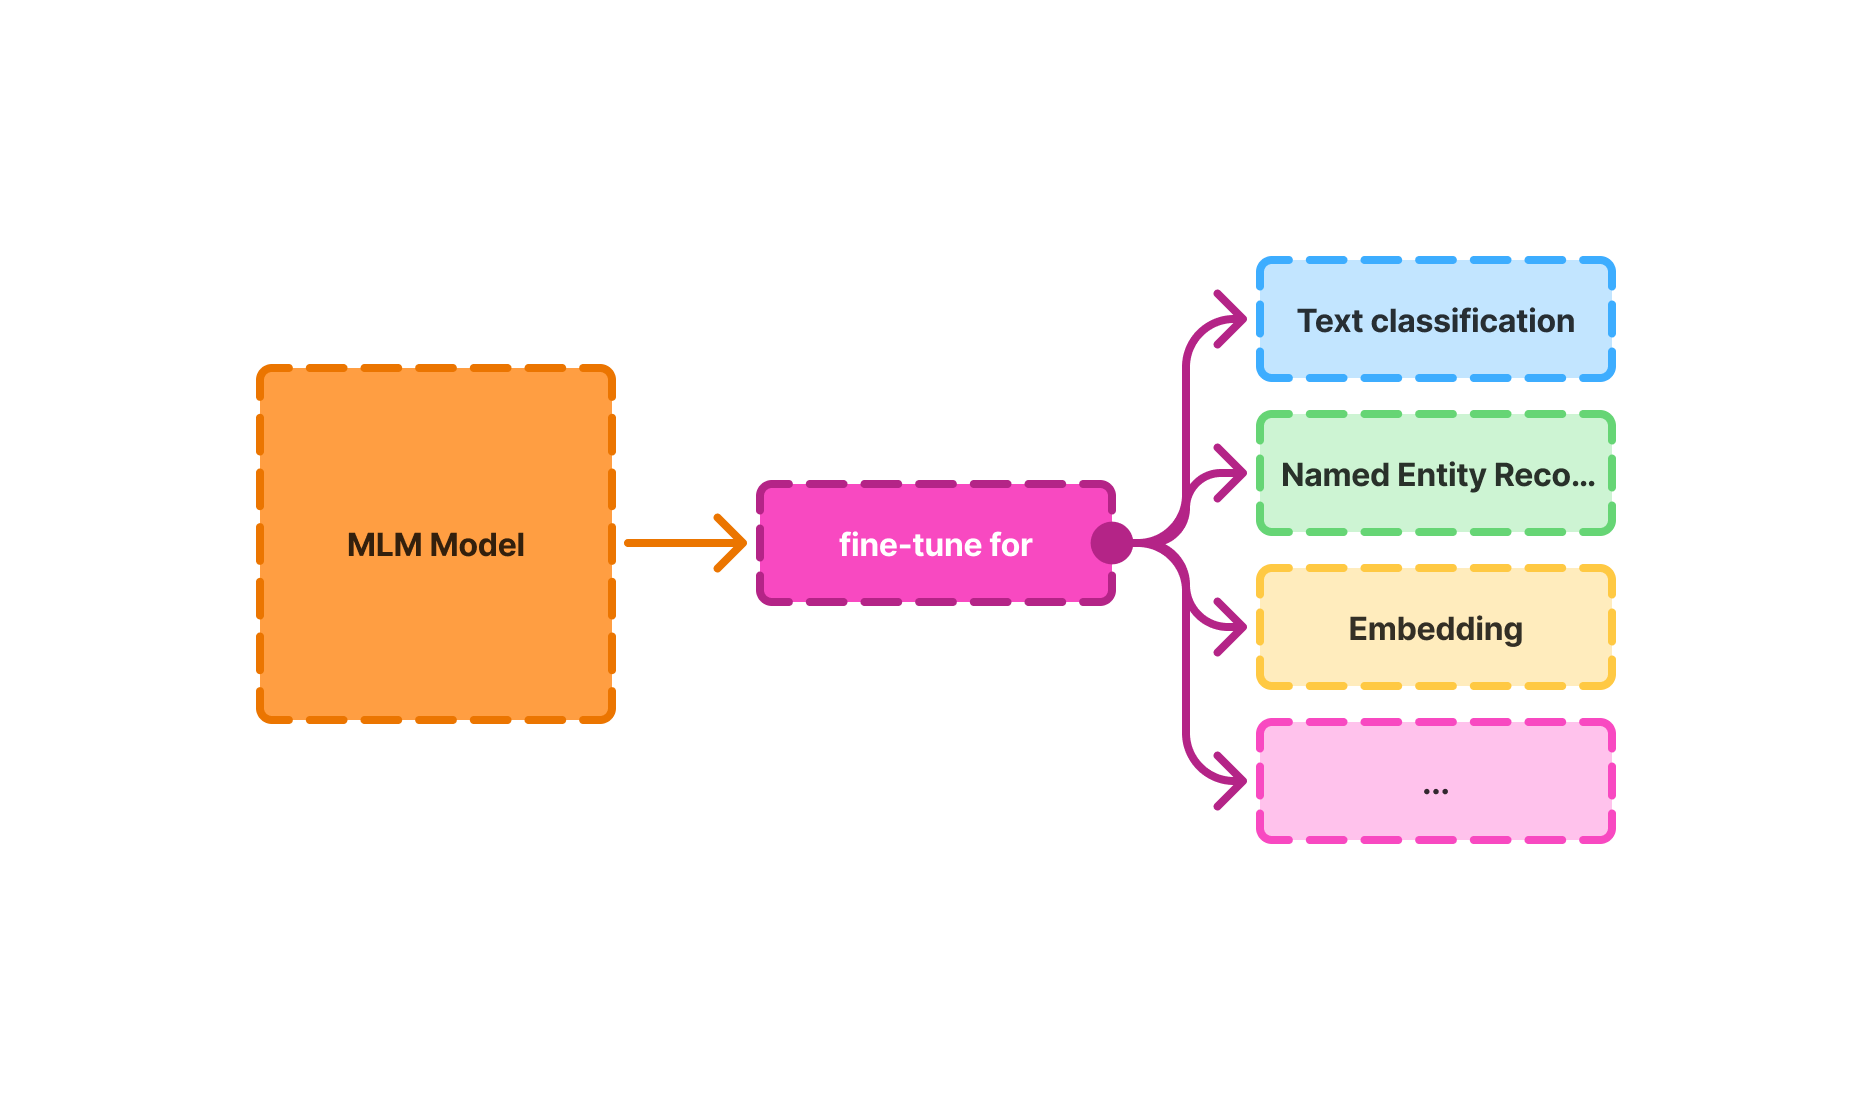

* ***BERT (Bidirectional encoder representations from transformers)***

> BERT inspired from the Transformer architecture introduced in "Attention is all you need", to become an encoder-only transformer that can produce meaningful representations and understand language.

> In the pretraining phase, BERT is trained to learn:
* **Masked Language Modeling**: is to predict masked words in a sentence (I [MASKED] this book before -> read)


* **Steps To Get Your BERT Model**
  - **RPT – Regular Pretraining (i.e., From Scratch)**

    * **Train a BERT model from scratch**, starting with **randomly initialized weights**.
    * Use **your own corpus** and perform MLM from the beginning.
    * **Goal**: Create a completely custom model tailored to a specific domain or language.
    * **Advantage**: Maximum control and domain alignment.
    * **Downside**: Requires huge amounts of data and computational resources.  

  - **CPT – Continued Pretraining (also called Domain-Adaptive Pretraining)**

    * **Start from** a general-purpose pretrained BERT model.
    * **Continue training** on your **own unlabeled data** using the same **Masked Language Modeling (MLM)** objective.
    * **Goal**: Adapt the model to your domain's vocabulary and style (e.g., medical, legal, scientific text).
    * **Advantage**: Fast and resource-efficient since you're not starting from scratch.

<center>

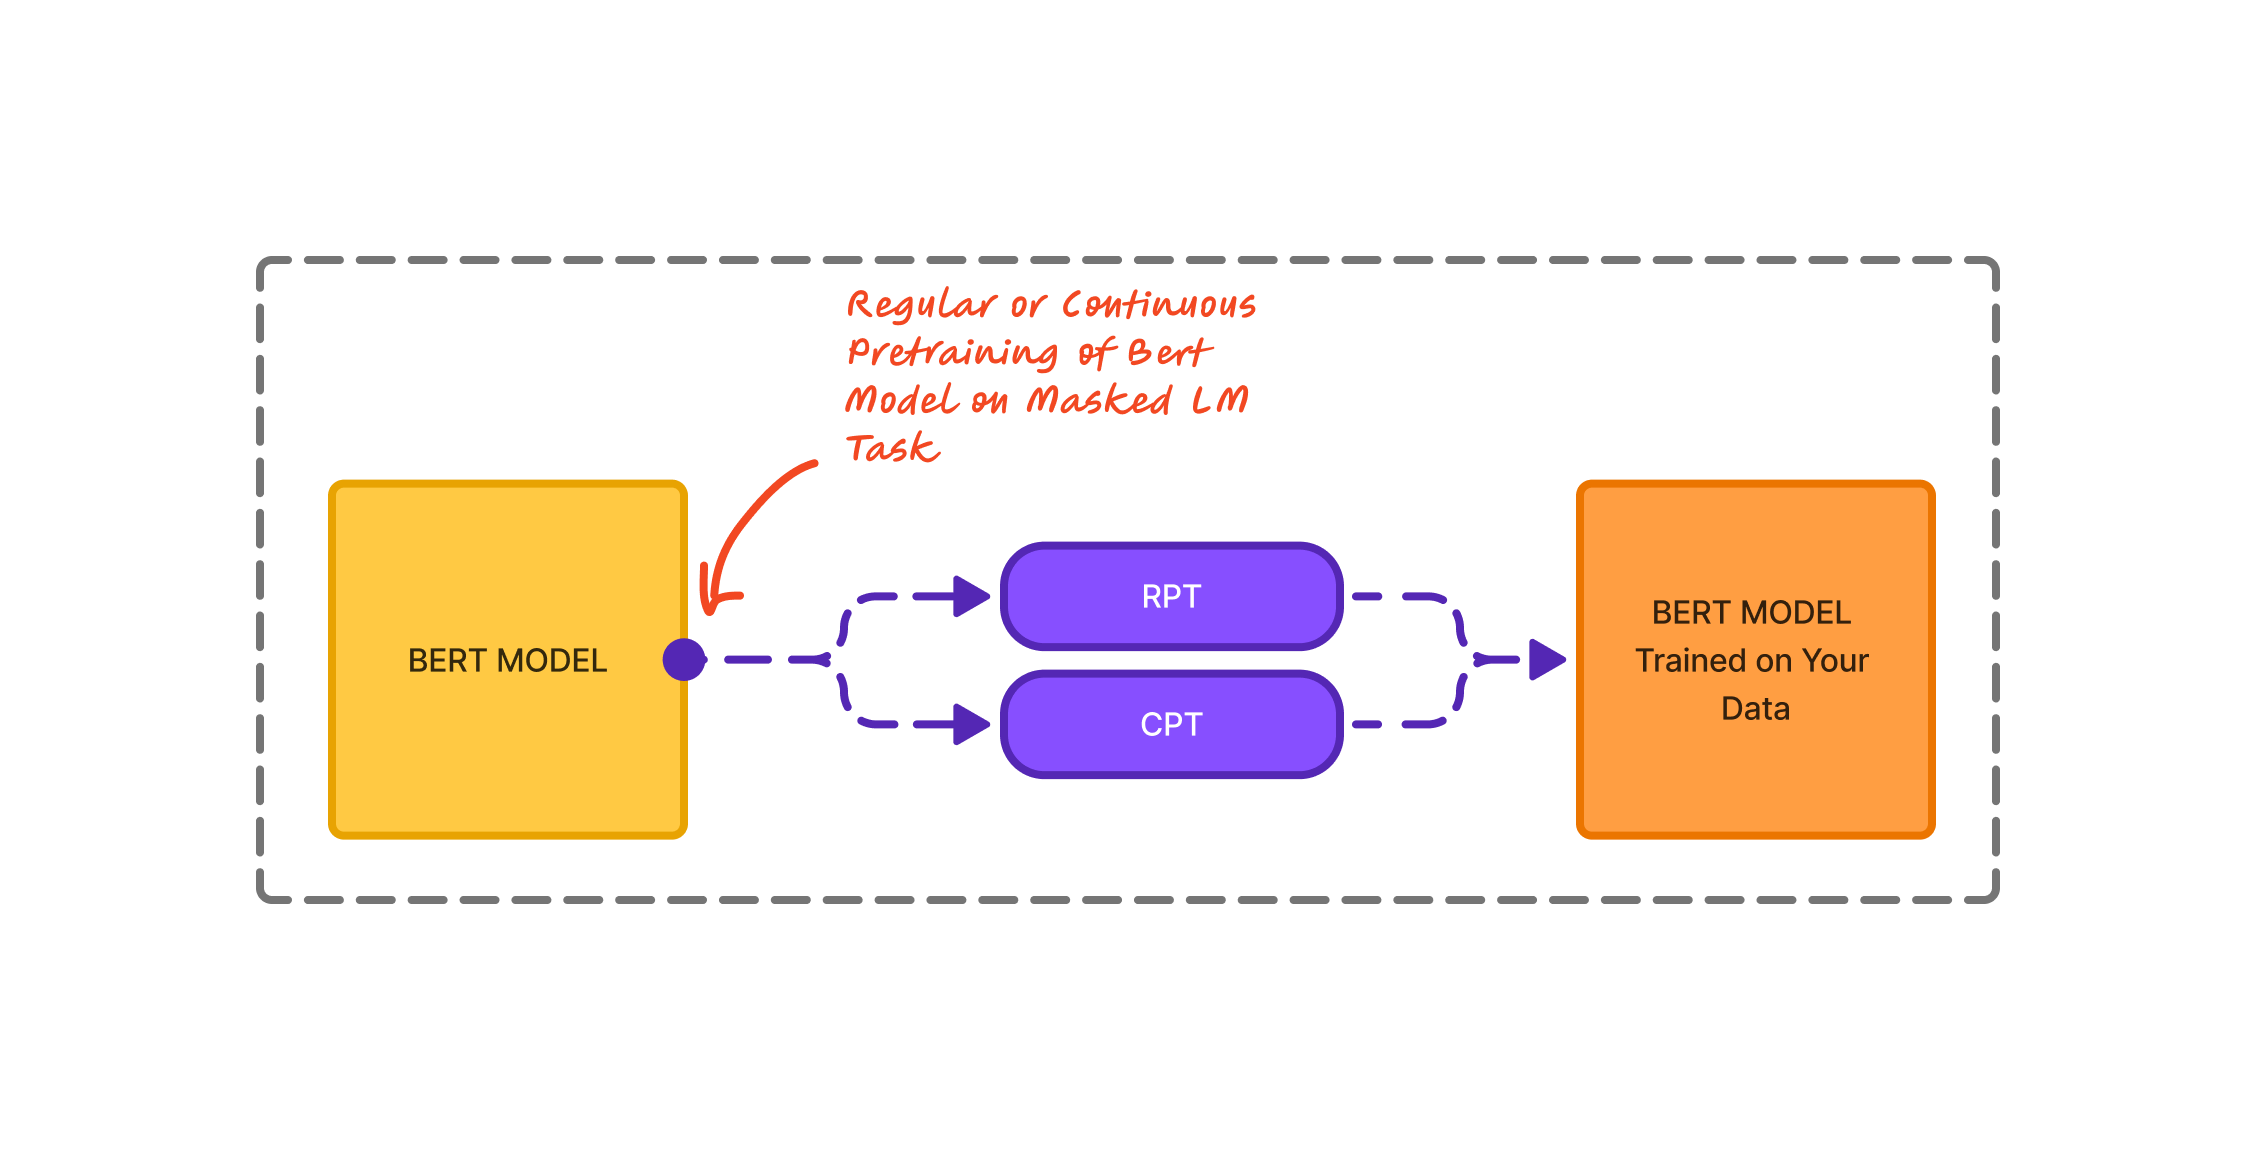
</center>
    




# Pretraining Bert Model (RPT/CPT) [Optional]

* As we said before in the pre-train phase, we train our model on masked lm task.
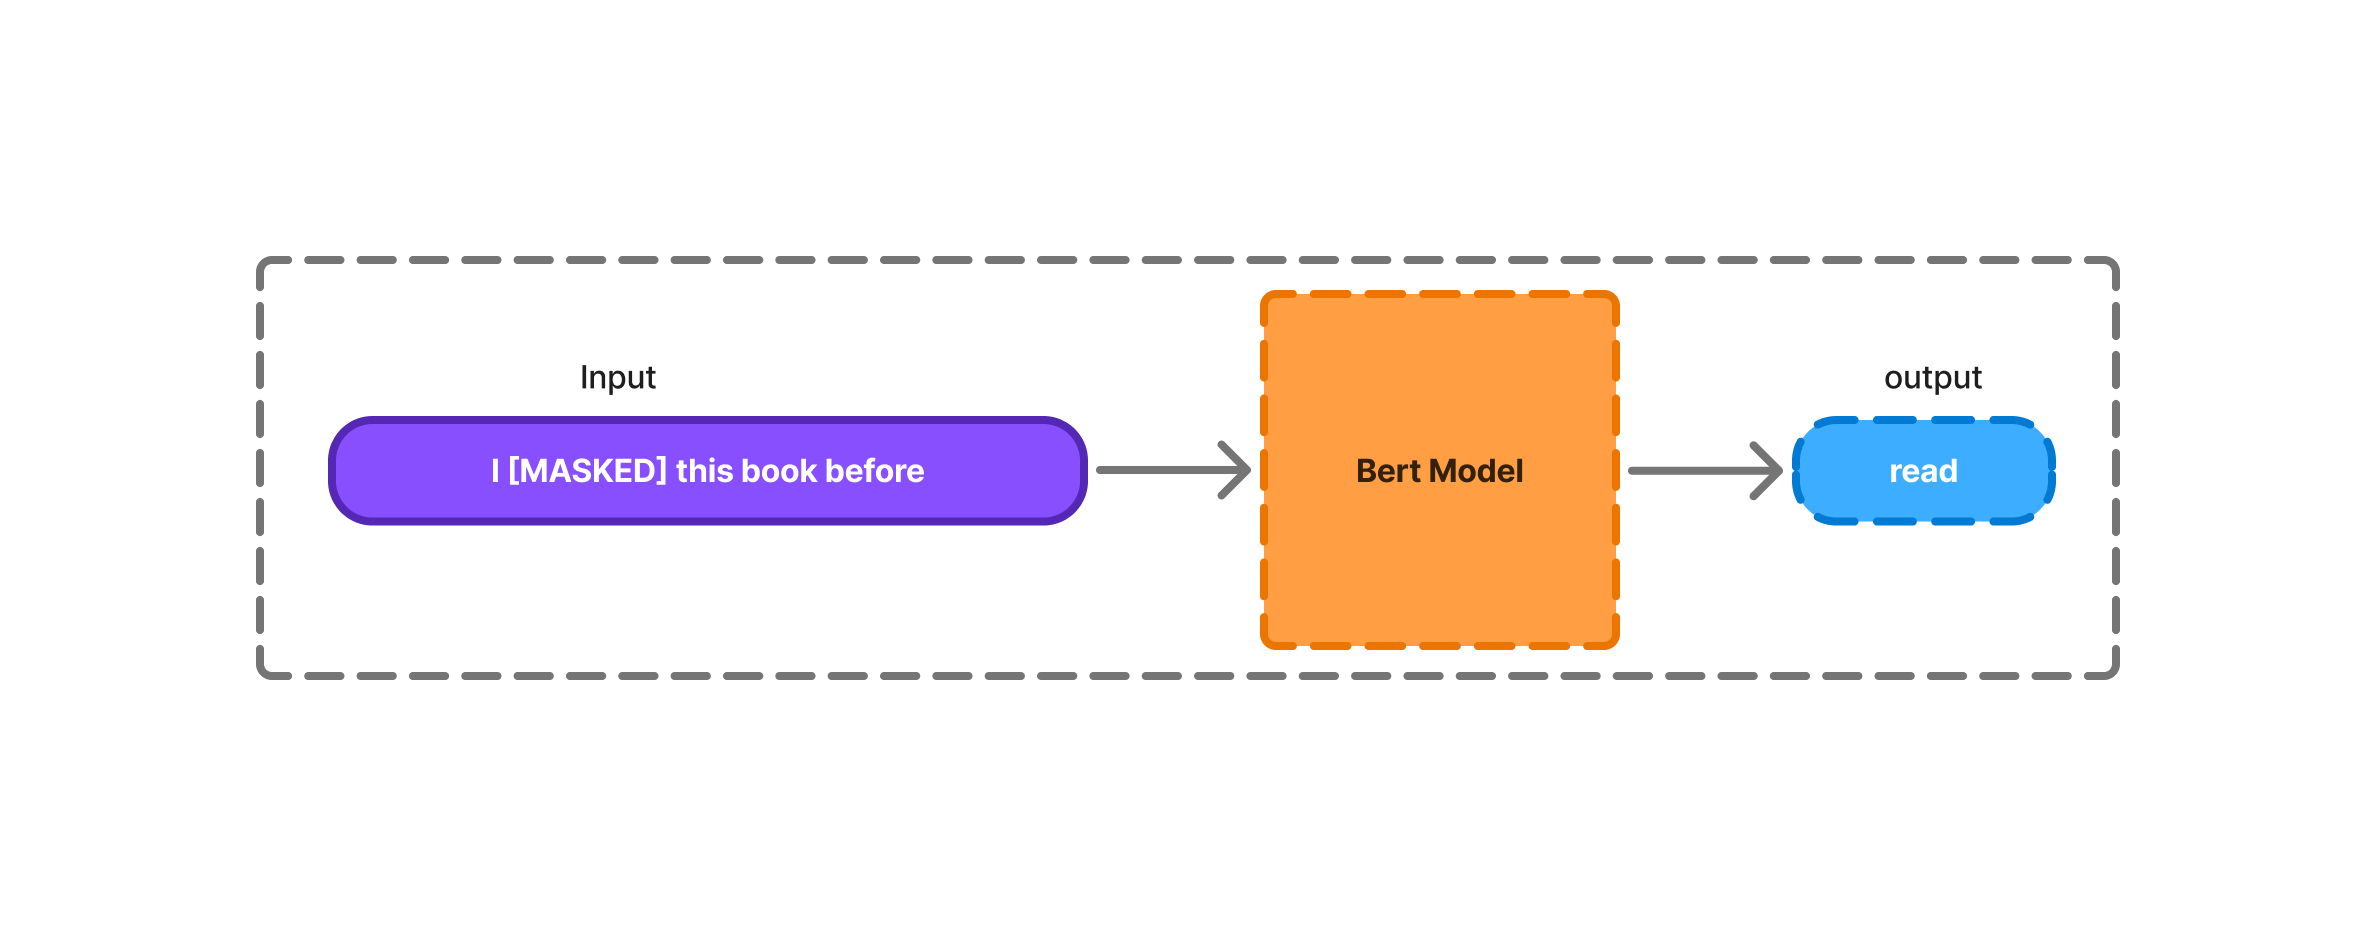

## Load Dataset from HF 🤗


In [ ]:
# install datasets
! pip install -U datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.1 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
ds = load_dataset("hackaix/mlm")
ds = ds["train"]
ds

README.md:   0%|          | 0.00/296 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/8.31k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'topic'],
    num_rows: 6
})

In [ ]:
ds.to_pandas()

,text,topic
0,الضيافة المغربية معروفة بزاف فالعالم، وكيبدا ه...,Traditional Cuisine and Hospitality
1,كازا مدينة ما كتنعسش، فيها الحركة والصداع، الن...,City Life
2,دابا فالعصر ديال التكنولوجيا، بزاف د الشباب ال...,Technology and Modern Work
3,السياحة فالمغرب عندها طابع خاص بفضل تنوع التضا...,Travel and Tourism
4,شحال كانت زوينة الطفولة ديالنا، كنا كنخرجو نلع...,Nostalgia and Childhood
5,العرس المغربي مناسبة ما كاينش بحالها فالعالم، ...,Moroccan weddings and celebrations


In [ ]:
# we will take only the text column
dataset = ds.select_columns(["text"])
dataset

Dataset({
    features: ['text'],
    num_rows: 6
})

In [ ]:
# split dataset train/test
dataset_splited = dataset.train_test_split(test_size=0.1)
dataset_splited

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 5
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1
    })
})

## Select Your BERT Model

- before data processing you need to select the bert model you want to train in huggingface, to do this follow the next steps:



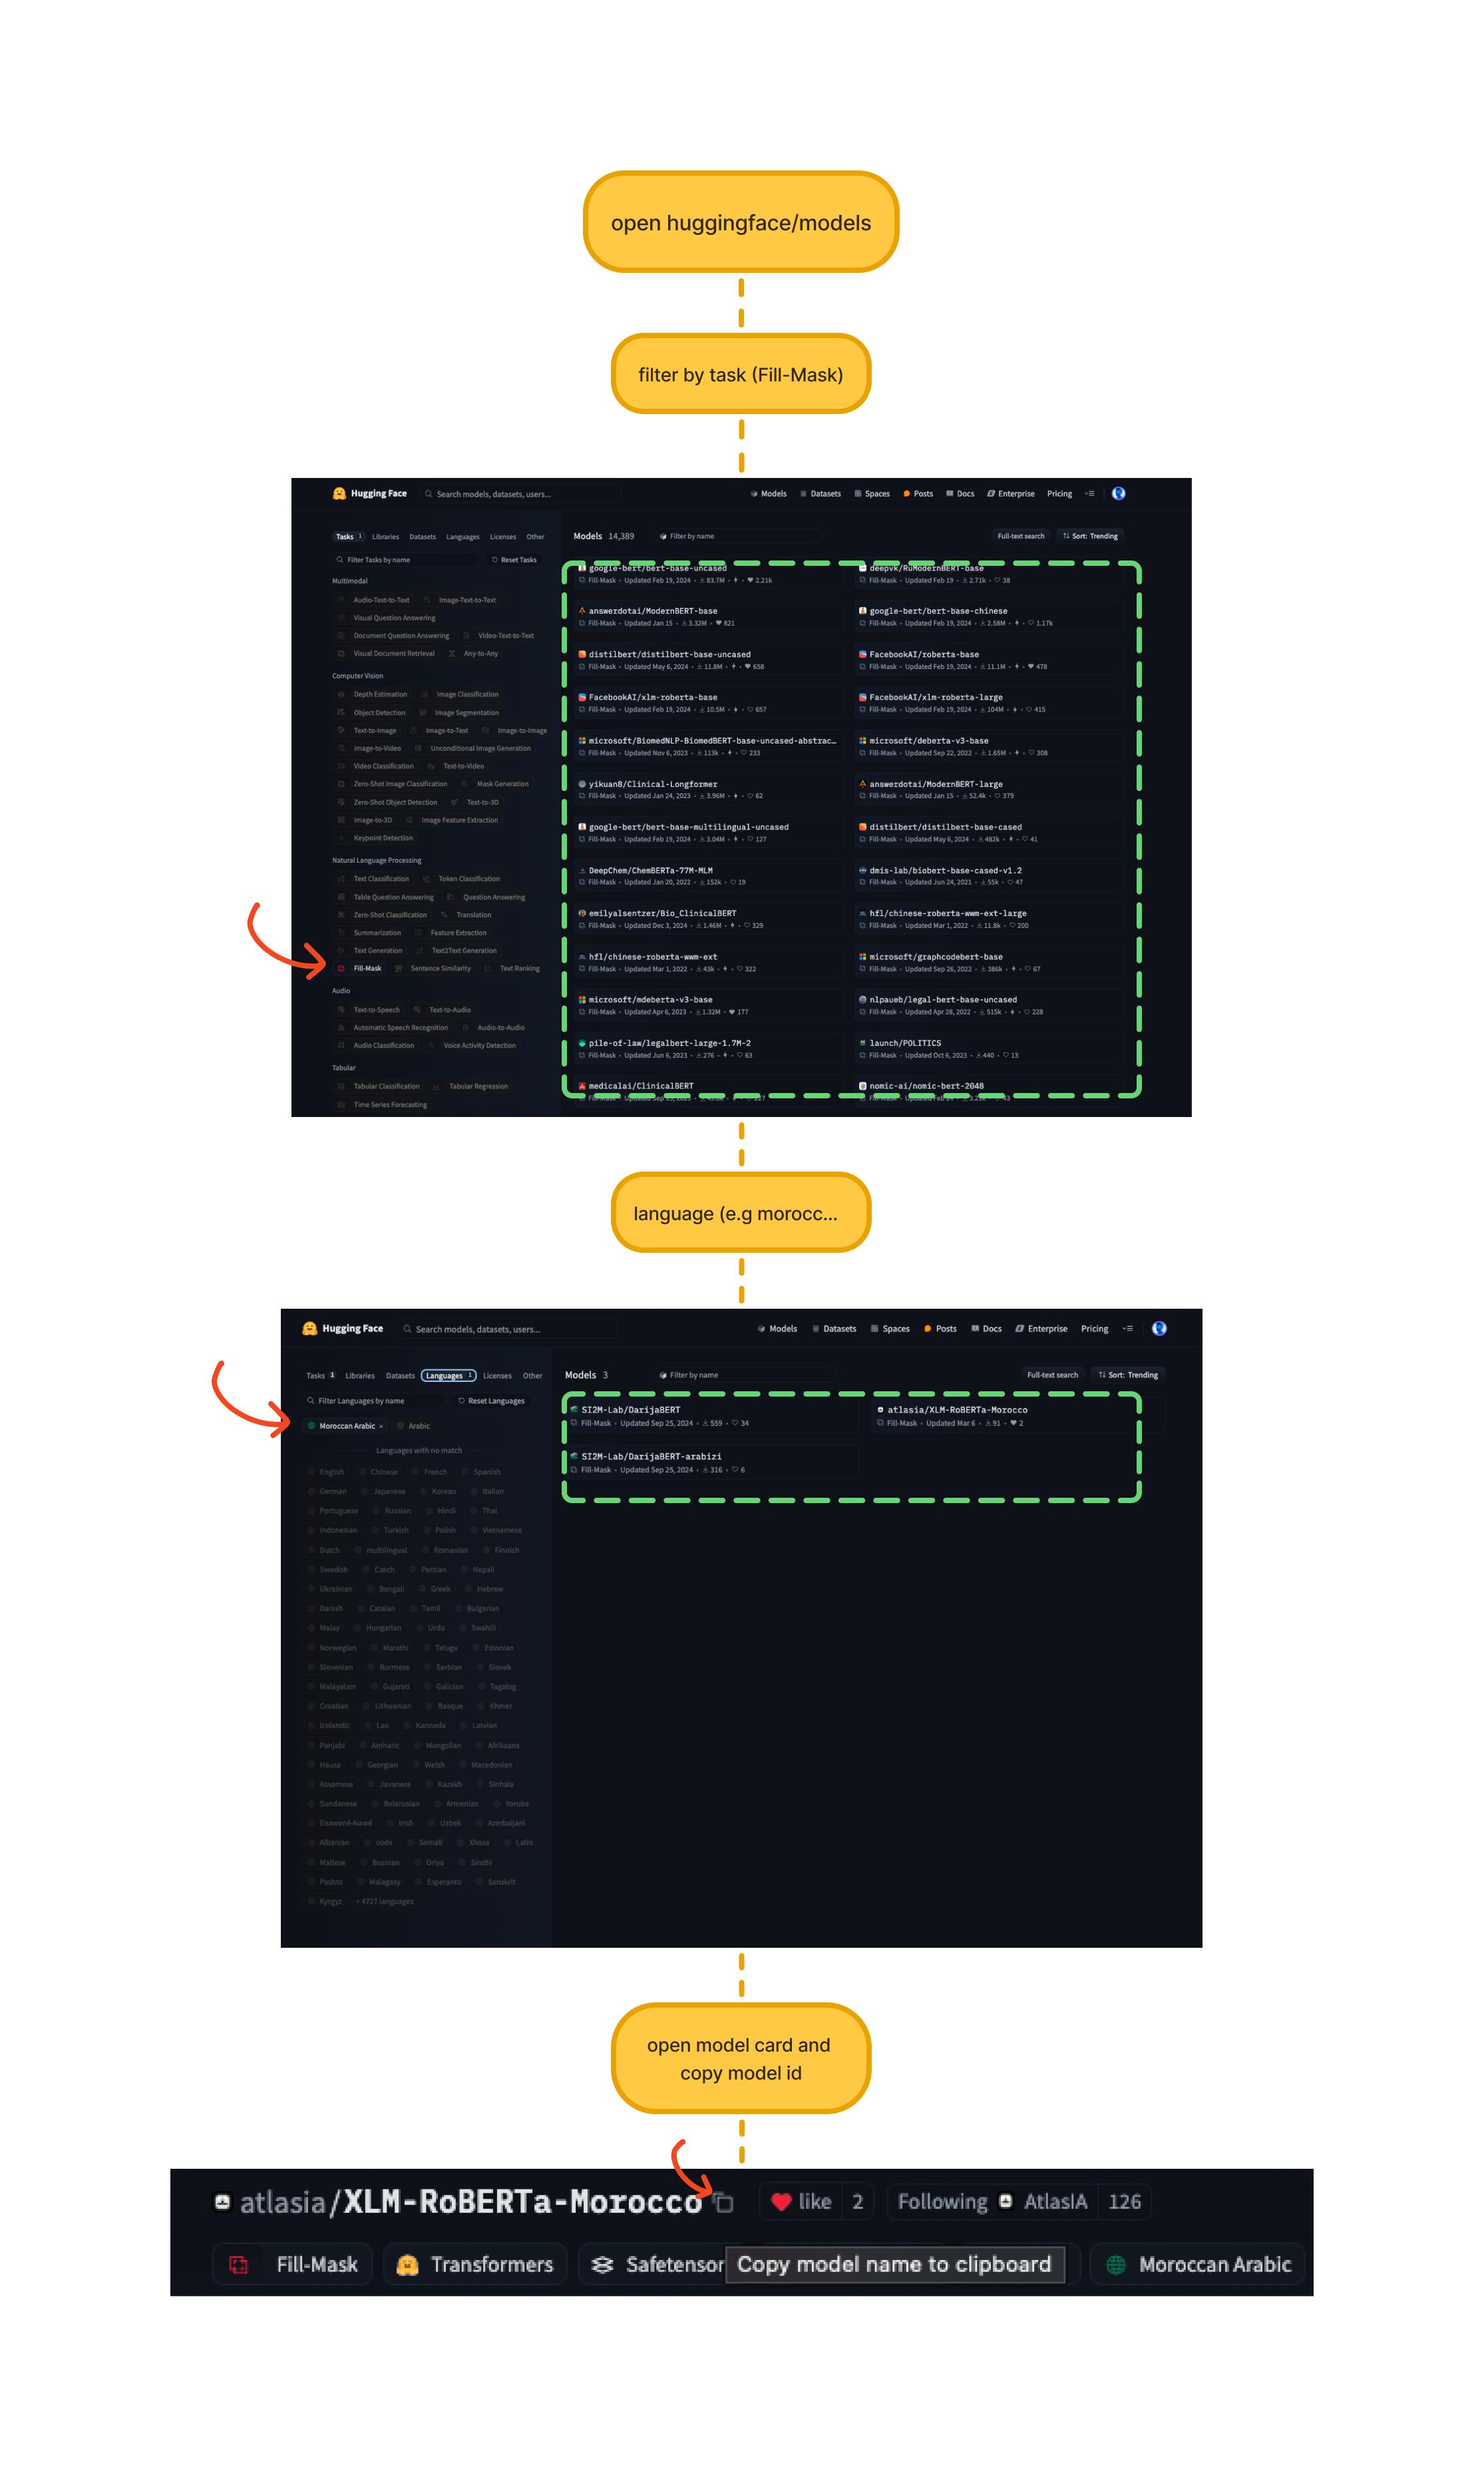

In [ ]:
from transformers import AutoConfig,AutoTokenizer,AutoModelForMaskedLM

In [ ]:
model_id = "atlasia/XLM-RoBERTa-Morocco"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# model_config = AutoConfig.from_pretrained(model_id) for RPT

model = AutoModelForMaskedLM.from_pretrained(model_id) # .from_config(model_config) for RPT

config.json:   0%|          | 0.00/753 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

## Data Processing

* Before we begin training our model, we need to prepare the data for our task (MLM).

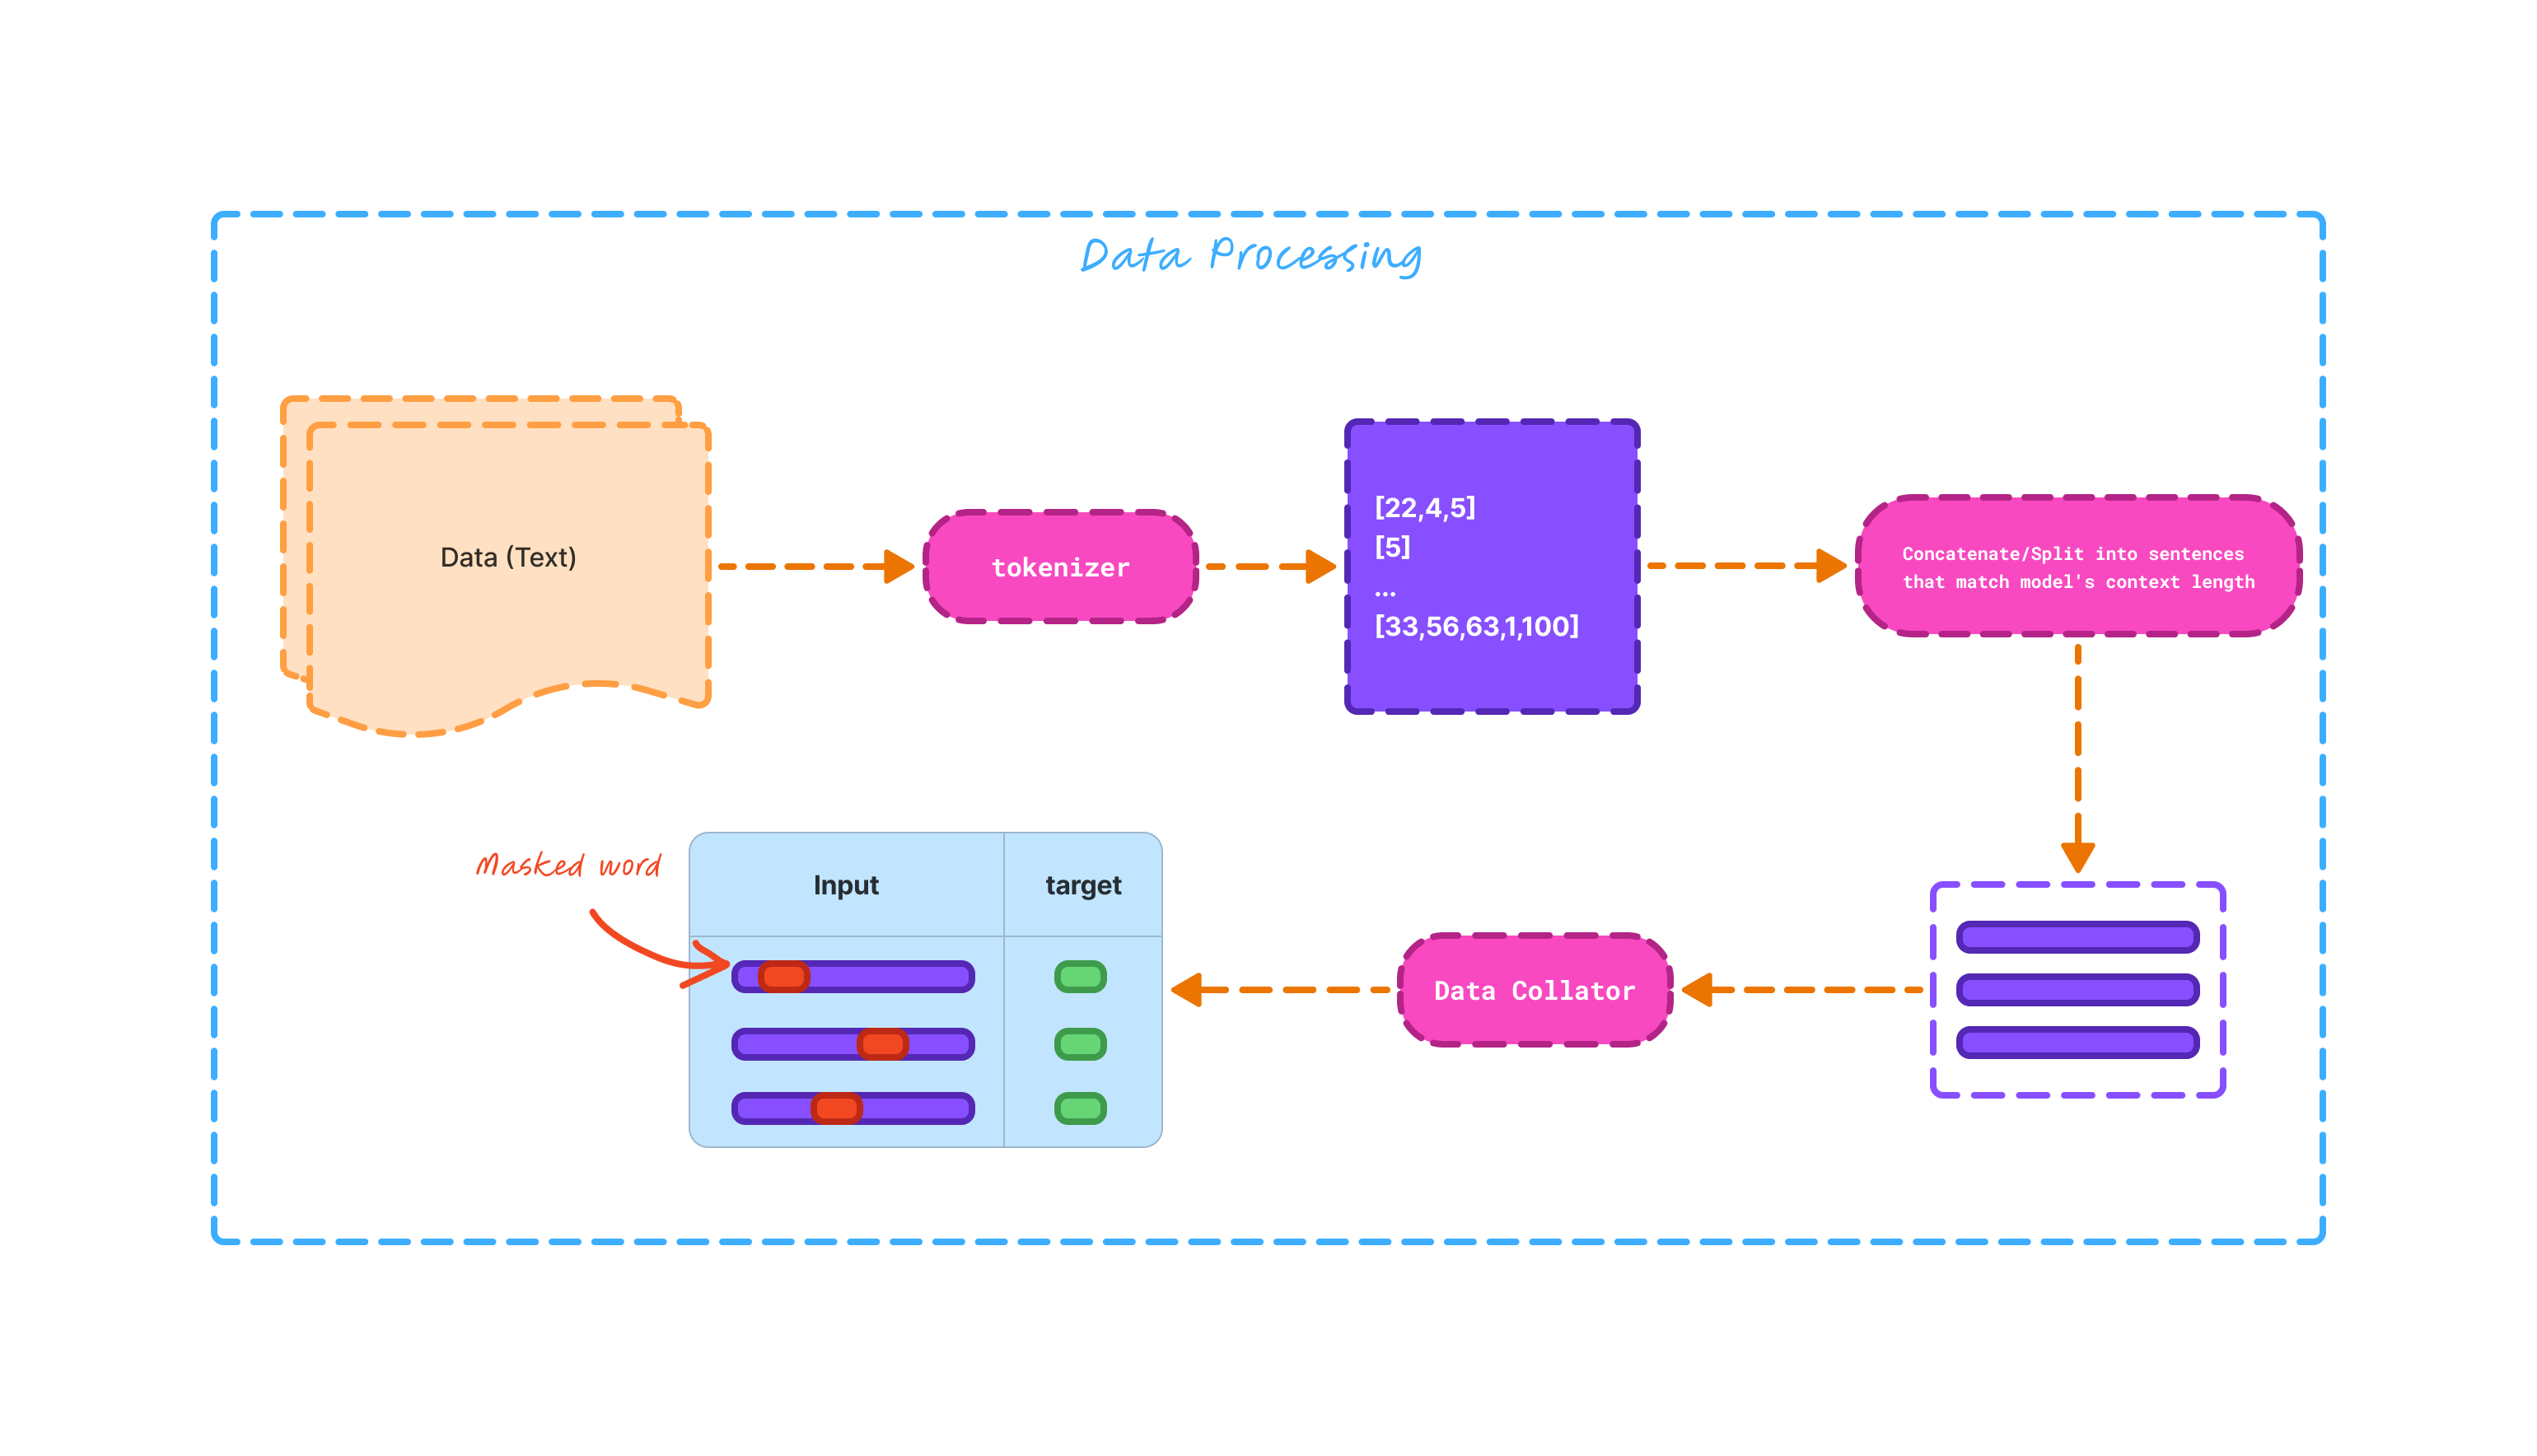

#### Data Tokenization

In [ ]:
def ds_tokenizer(examples):
  return tokenizer(examples["text"])

In [ ]:
train_tokenized=dataset_splited["train"].map(ds_tokenizer).remove_columns(dataset_splited["train"].column_names)
eval_tokenized=dataset_splited["test"].map(ds_tokenizer).remove_columns(dataset_splited["test"].column_names)
train_tokenized, eval_tokenized

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

(Dataset({
     features: ['input_ids', 'attention_mask'],
     num_rows: 5
 }),
 Dataset({
     features: ['input_ids', 'attention_mask'],
     num_rows: 1
 }))

In [ ]:
train_tokenized.to_pandas()

,input_ids,attention_mask
0,"[0, 33149, 17113, 30522, 877, 4316, 17642, 119...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,"[0, 205309, 22107, 376, 85550, 11020, 608, 711...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,"[0, 5537, 12323, 176827, 16080, 250, 877, 3314...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,"[0, 3039, 6779, 22107, 1195, 24370, 3015, 1282...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,"[0, 5322, 37811, 9642, 78027, 67020, 359, 4553...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


#### Conctenate/Splite

In [ ]:
context_length = 256
def concatenate_splite(examples):
    # Concatenate all texts.
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples["input_ids"])
    if total_length >= context_length:
        total_length = (total_length // context_length) * context_length
    # Split by chunks of context_length.
    result={"input_ids":[],"attention_mask":[]}
    for k,v in concatenated_examples.items():
      for i in range(0,len(v),context_length):
        result[k].append(v[i:i+context_length])
    return result

In [ ]:
train_ds=train_tokenized.map(concatenate_splite,batched=True)
eval_ds=eval_tokenized.map(concatenate_splite,batched=True)

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

#### DataCollator

In [ ]:
from transformers import DataCollatorForLanguageModeling

In [ ]:
data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer,mlm=True,mlm_probability=0.2) # mlm: how much i will mask in sentence (e.g 20%)

## Training

> After preparing our model and the data for training, the **training arguments** component remained to run our training

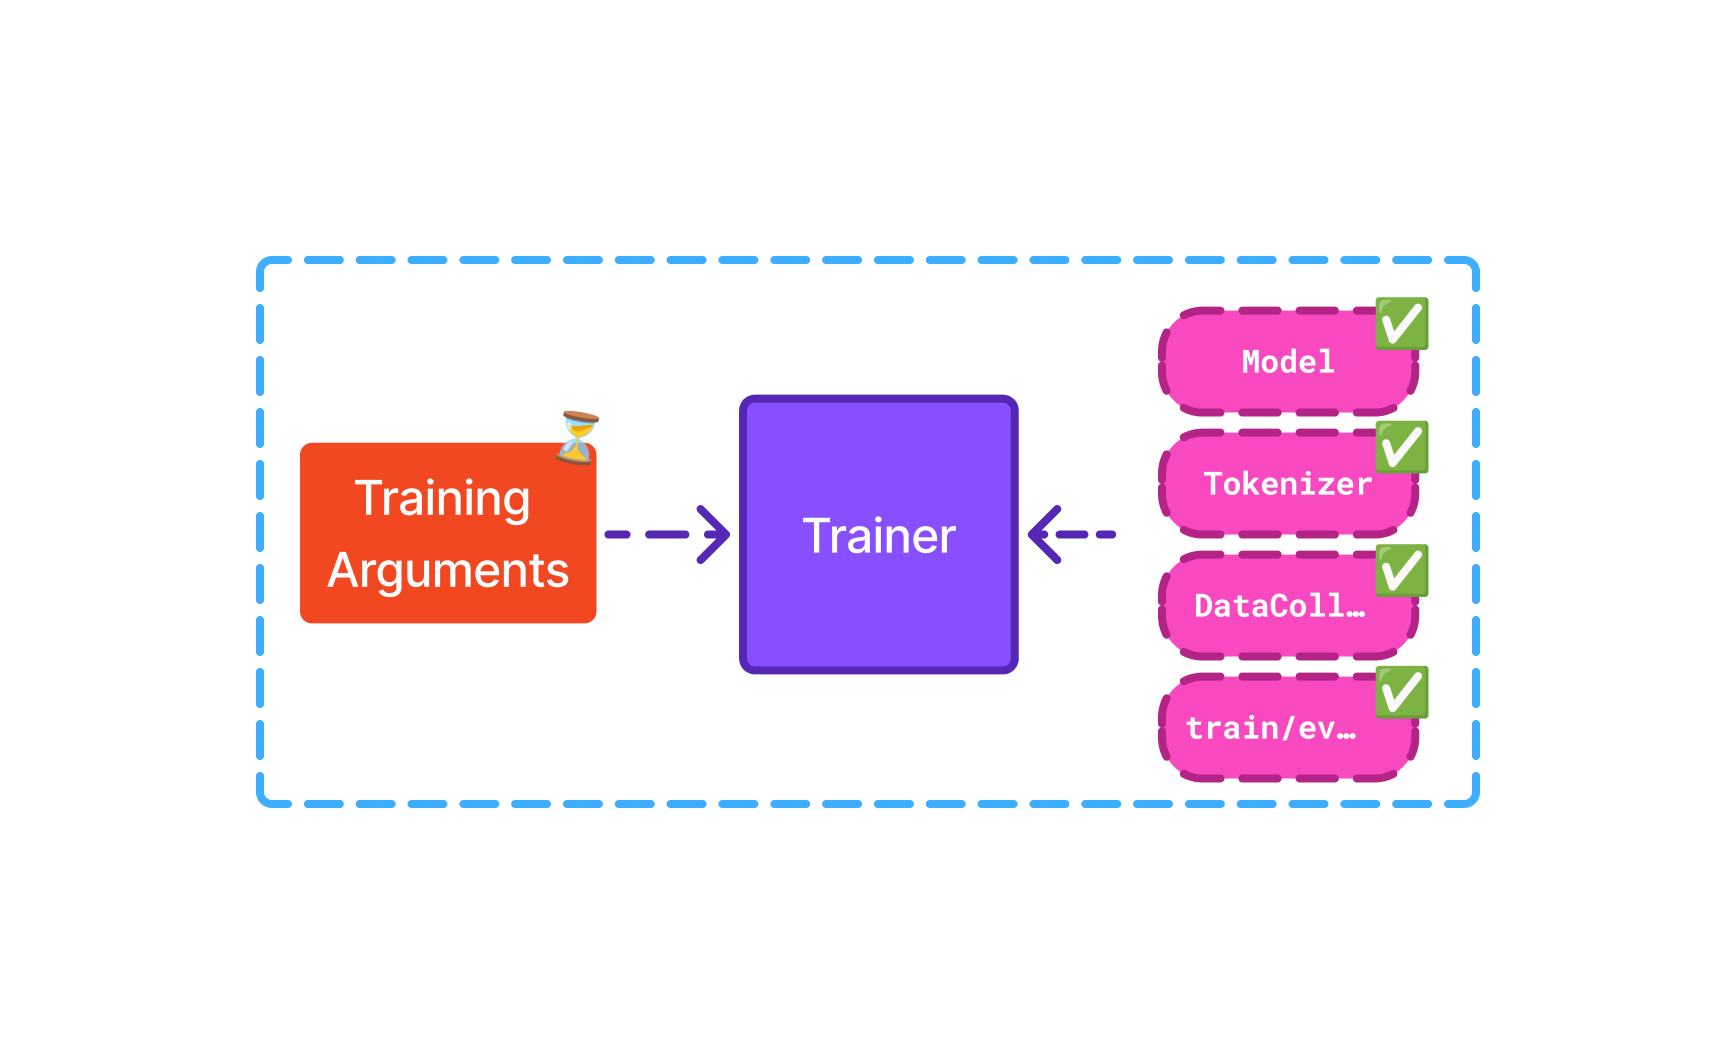

#### Training Arguments

In [ ]:
# trainer
from transformers import TrainingArguments,Trainer
args=TrainingArguments(
    "bert-mlm",
    learning_rate=2e-5,
    per_device_eval_batch_size=8,
    per_device_train_batch_size=4,
    num_train_epochs=1,
    save_total_limit=2,
    weight_decay=0.01,
    eval_steps=1000,
    logging_steps=1000,
    warmup_ratio=0.03,
    fp16=True,
    gradient_checkpointing=True,
    gradient_accumulation_steps=4,
    report_to="wandb",
    run_name="Bert CPT"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


#### Trainer

In [ ]:
trainer=Trainer(
    model=model,
    # tokenizer=tokenizer,
    data_collator=data_collator,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    args=args
)

#### Check GPU & Start Training

In [ ]:
! nvidia-smi # if the result is not found => there's no nvidia gpus

Thu May 14 08:36:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             27W /   70W |    2259MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: WARNING Invalid choice
wandb: Enter your choice:

 (3)


wandb: WARNING Invalid choice
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1, training_loss=1.186972975730896, metrics={'train_runtime': 367.8455, 'train_samples_per_second': 0.011, 'train_steps_per_second': 0.003, 'total_flos': 3438275309568.0, 'train_loss': 1.186972975730896, 'epoch': 1.0})

#### Push Model to the hub

In [ ]:
trainer.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t/model/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...tent/model/tokenizer.json: 100%|##########| 16.8MB / 16.8MB            

  ...t/model/model.safetensors:   1%|1         | 32.0MB / 2.24GB            

CommitInfo(commit_url='https://huggingface.co/KBayoud/model/commit/c4f0ca44cb32f4f407aa71f8ea295ff70b38c270', commit_message='KBayoud/test-bert-mlm', commit_description='', oid='c4f0ca44cb32f4f407aa71f8ea295ff70b38c270', pr_url=None, repo_url=RepoUrl('https://huggingface.co/KBayoud/model', endpoint='https://huggingface.co', repo_type='model', repo_id='KBayoud/model'), pr_revision=None, pr_num=None)

## Show Your Work (Model Space) at Hugging Face

**In this final step, you will create a Gradio Space on Hugging Face to showcase your work. Follow these steps:**

1. **Clone the repository** from this [space](https://huggingface.co/spaces/atlasia/Masked-LM-Moroccan-Darija).

<cneter>

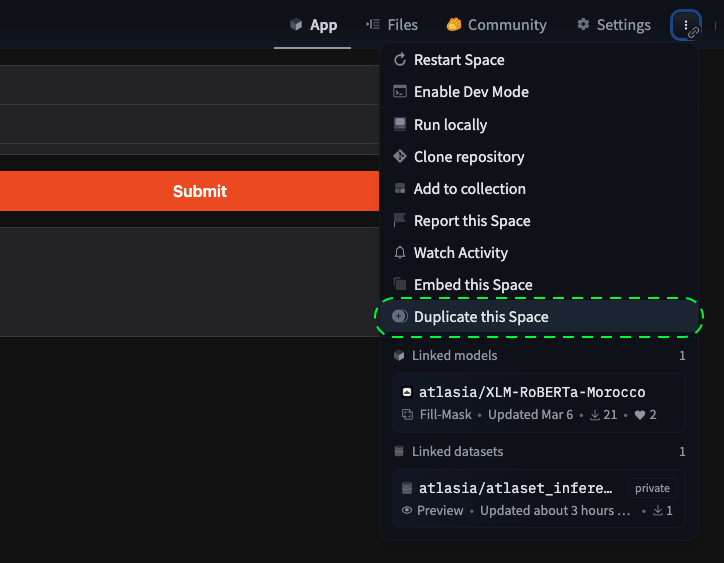
</center>

2. **Open the code files** and **replace the model ID** with the ID of your own trained MLM model.

<center>

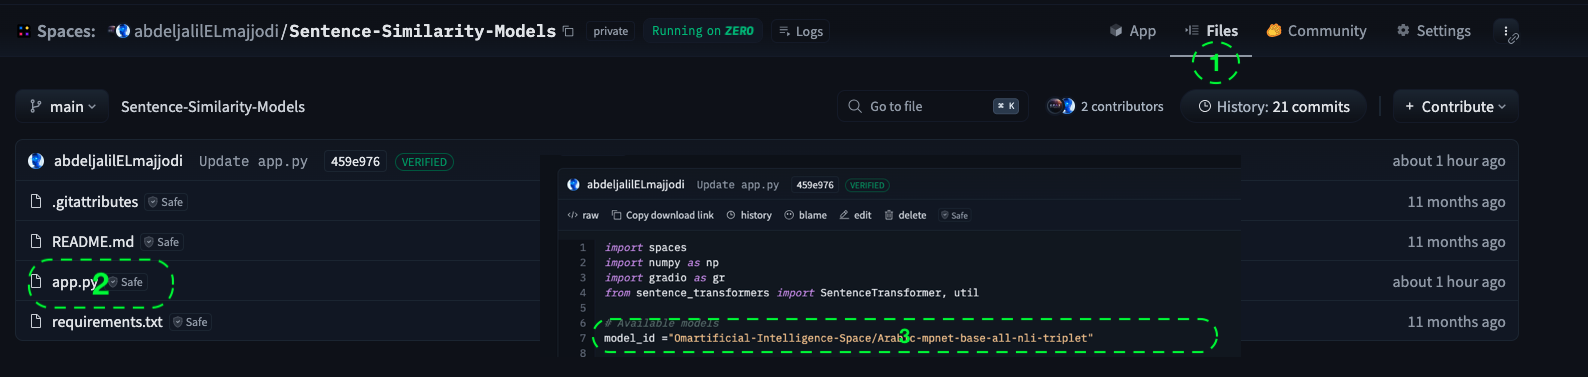
</center>

3. **Update the example inputs** to be compatible with your model’s expected format (e.g., appropriate masked sentences).
4. **Save and commit your changes**, then save changes.
